# Shallow xLSTM Benchmark with Optuna & Symlog

In [9]:
!pip install optuna xlstm

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import optuna

from xlstm import (
    xLSTMBlockStack,
    xLSTMBlockStackConfig,
    sLSTMBlockConfig,
    mLSTMBlockConfig,
    sLSTMLayerConfig,
    mLSTMLayerConfig
)


DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 70
PATIENCE = 10
TRAIN_YEAR_CUTOFF = 2020
VALID_YEAR_CUTOFF = 2022
OPTUNA_TRIALS = 50
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Loading - Improved Pipeline

In [11]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()

    exclude_cols = {"Date", "Company", "year", "has_targets"} | set(PREDICTION_TARGETS)
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            historical_data = company_data[company_data["Date"] <= year_end_date]
            if len(historical_data) < lookback_days:
                continue

            window = historical_data.tail(lookback_days).copy()

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue
            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)
            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"]
            })

    return pd.DataFrame(data_records), feature_cols

def split_by_year(data_df: pd.DataFrame, train_cutoff: int, valid_cutoff: int):
    train_data = data_df[data_df["year"] <= train_cutoff].copy()
    val_data = data_df[(data_df["year"] > train_cutoff) & (data_df["year"] <= valid_cutoff)].copy()
    test_data = data_df[data_df["year"] > valid_cutoff].copy()
    return train_data, val_data, test_data

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

# --- LOCK IN BEST PIPELINE: SYMLOG & ROBUST SCALER ---
improved_data_df = data_df.copy()
idx_value = improved_data_df["target"].isin(PREDICTION_TARGETS)
y_val = improved_data_df.loc[idx_value, "label_value"]
improved_data_df.loc[idx_value, "label_value"] = np.sign(y_val) * np.log1p(np.abs(y_val))

train_data_imp, val_data_imp, test_data_imp = split_by_year(improved_data_df, TRAIN_YEAR_CUTOFF, VALID_YEAR_CUTOFF)

selected_indices = [feature_cols.index(f) for f in feature_cols]
robust_scaler = RobustScaler()
train_windows_imp = np.vstack([row[:, selected_indices] for row in train_data_imp["window_data"]])
robust_scaler.fit(train_windows_imp)
print(f"Data Processed. Training sets: {len(train_data_imp)}")

Data Processed. Training sets: 3606


## Dataset and Multi-Task Preparation

In [12]:
def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

mtl_train_data = extract_mtl_df(train_data_imp)
mtl_val_data = extract_mtl_df(val_data_imp)
mtl_test_data = extract_mtl_df(test_data_imp)

class ImprovedYoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices

    def __len__(self): return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.scaler: window = self.scaler.transform(window)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return torch.from_numpy(window), torch.tensor(target_clean, dtype=torch.float32), torch.tensor(mask, dtype=torch.bool), len(window)

def collate_fn_improved_mtl(batch):
    batch.sort(key=lambda x: x[3], reverse=True)
    sequences = [x[0] for x in batch]
    targets = torch.stack([x[1] for x in batch])
    masks = torch.stack([x[2] for x in batch])
    lengths = torch.tensor([x[3] for x in batch])
    # xLSTM does not use torch packing natively. We feed it zero-padded batches.
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, lengths

## xLSTM Model Architecture definition

Since `xLSTM` relies strictly on matrix processing, zero-padded `batch_first` tensors are used instead of `PyTorch pack_padded` utilities, taking care to extract only the actual final hidden state per element based on the masking lengths.

In [13]:
class ImprovedShallow_xLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = len(PREDICTION_TARGETS), dropout: float = 0.2, block_type: str = 'mlstm'):
        super().__init__()
        self.proj = nn.Linear(input_size, hidden_size)
        slstm_config = sLSTMLayerConfig(backend='vanilla')

        self.xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(slstm=slstm_config),
            mlstm_block=mLSTMBlockConfig(mlstm=mLSTMLayerConfig()),
            context_length=400, # Large enough to encompass max lookback sequence limits
            num_blocks=1, # Depth 1, strictly comparing to shallow LSTM
            embedding_dim=hidden_size,
            slstm_at=[0] if block_type == 'slstm' else []
        )

        self.xlstm = xLSTMBlockStack(self.xlstm_config)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size, num_targets)

    def forward(self, x, lengths):
        # x shape: [B, MaxSeq, input_size]
        B, S, _ = x.shape
        x_proj = self.proj(x)

        # Output strictly structured as [B, S, hidden_dim]
        out = self.xlstm(x_proj)

        # Dynamically recover the 'last valid hidden step' taking sequence padding into account
        idx = (lengths - 1).view(-1, 1).expand(-1, out.size(2)).unsqueeze(1).to(out.device)
        last_out = out.gather(1, idx).squeeze(1) # [B, hidden_size]

        hidden = self.dropout(last_out)
        logits = self.head(hidden)

        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

In [14]:
class TunableHybrid_xLSTM(nn.Module):
    def __init__(self, input_size: int, embedding_dim: int, mlstm_proj_factor: float,
                 mlstm_num_heads: int, slstm_hidden_size: int, dropout_mlstm: float,
                 dropout_slstm: float, dropout_global: float, num_targets: int = len(PREDICTION_TARGETS)):
        super().__init__()
        self.proj = nn.Linear(input_size, embedding_dim)

        slstm_config = sLSTMLayerConfig(
            backend='vanilla',
            hidden_size=slstm_hidden_size,
            dropout=dropout_slstm
        )

        mlstm_config = mLSTMLayerConfig(
            num_heads=mlstm_num_heads,
            proj_factor=mlstm_proj_factor,
            dropout=dropout_mlstm
        )

        # ... (rest of the __init__ and forward pass remain exactly the same)

        self.xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(slstm=slstm_config),
            mlstm_block=mLSTMBlockConfig(mlstm=mlstm_config),
            context_length=400,
            num_blocks=3,
            embedding_dim=embedding_dim,
            slstm_at=[2] # Block 0 & 1 are mLSTM, Block 2 is sLSTM
        )

        self.xlstm = xLSTMBlockStack(self.xlstm_config)
        self.head_dropout = nn.Dropout(p=dropout_global)
        self.head = nn.Linear(embedding_dim, num_targets)

    def forward(self, x, lengths):
        B, S, _ = x.shape
        out = self.proj(x)
        out = self.xlstm(out)

        idx = (lengths - 1).view(-1, 1).expand(-1, out.size(2)).unsqueeze(1).to(out.device)
        last_out = out.gather(1, idx).squeeze(1)

        hidden = self.head_dropout(last_out)
        logits = self.head(hidden)

        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

def objective_hybrid(trial):
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = True
    # Core transport bus dimension
    embedding_dim = trial.suggest_categorical("embedding_dim", [32, 64, 128])

    # mLSTM specific settings (Matrix capacity)
    mlstm_proj_factor = trial.suggest_categorical("mlstm_proj_factor", [1.0, 1.5, 2.0])
    mlstm_num_heads = trial.suggest_categorical("mlstm_num_heads", [2, 4])

    # Prune immediately if embedding_dim cannot be evenly divided by heads
    if embedding_dim % mlstm_num_heads != 0:
        raise optuna.TrialPruned()

    # sLSTM specific settings (Scalar tracking capacity)
    slstm_hidden_size = trial.suggest_categorical("slstm_hidden_size", [16, 32, 64])

    # Regularization
    dropout_mlstm = trial.suggest_float("dropout_mlstm", 0.1, 0.4)
    dropout_slstm = trial.suggest_float("dropout_slstm", 0.1, 0.4)
    dropout_global = trial.suggest_float("dropout_global", 0.2, 0.5)

    # Optimizer & Training
    lr_mlstm = trial.suggest_float("lr_mlstm", 1e-4, 5e-3, log=True)
    lr_slstm = trial.suggest_float("lr_slstm", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_ds = ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices)
    val_ds = ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_improved_mtl)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

    model = TunableHybrid_xLSTM(
        input_size=len(selected_indices),
        embedding_dim=embedding_dim,
        mlstm_proj_factor=mlstm_proj_factor,
        mlstm_num_heads=mlstm_num_heads,
        slstm_hidden_size=slstm_hidden_size,
        dropout_mlstm=dropout_mlstm,
        dropout_slstm=dropout_slstm,
        dropout_global=dropout_global
    )

    mlstm_params = [p for n, p in model.named_parameters() if 'mlstm' in n]
    slstm_params = [p for n, p in model.named_parameters() if 'slstm' in n]
    other_params = [p for n, p in model.named_parameters() if 'mlstm' not in n and 'slstm' not in n]

    optimizer = torch.optim.AdamW([
        {'params': mlstm_params, 'lr': lr_mlstm},
        {'params': slstm_params, 'lr': lr_slstm},
        {'params': other_params, 'lr': lr_mlstm}
    ], weight_decay=weight_decay)

    criterion = RealScaleL1Loss()
    val_loss = train_model_v2(model, train_loader, val_loader, criterion, optimizer,
                           epochs=MAX_EPOCHS, patience=PATIENCE, device=DEVICE, trial=trial)

    return val_loss

## Optuna & Training Loop Helper

In [15]:
def inverse_symlog_tensor(values):
    return torch.sign(values) * torch.expm1(torch.abs(values))

class RealScaleL1Loss(nn.Module):
    def forward(self, preds_symlog, targets_symlog):
        preds_real = inverse_symlog_tensor(preds_symlog)
        targets_real = inverse_symlog_tensor(targets_symlog)
        return torch.mean(torch.abs(preds_real - targets_real))

def train_model(model, train_loader, val_loader, criterion, lr, weight_decay, epochs, patience, device, trial=None):
    model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )

    best_loss = float('inf')
    best_epoch = -1
    early_stop_counter = 0
    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_valid_count = 0

        for x_batch, y_batch, mask_batch, lengths in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)
            lengths = lengths.to(device)

            if mask_batch.sum() == 0:
                continue

            optimizer.zero_grad()
            preds = model(x_batch, lengths)
            valid_count = mask_batch.sum().item()

            loss = criterion(
                preds[mask_batch],
                y_batch[mask_batch]
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            train_loss += loss.item() * valid_count
            train_valid_count += valid_count

        train_loss /= max(1, train_valid_count)

        model.eval()

        val_real_mae = 0.0
        val_valid_count = 0

        with torch.no_grad():

            for x_batch, y_batch, mask_batch, lengths in val_loader:

                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                mask_batch = mask_batch.to(device)
                lengths = lengths.to(device)

                if mask_batch.sum() == 0:
                    continue

                preds = model(x_batch, lengths)

                valid_count = mask_batch.sum().item()

                preds_real = inverse_symlog_tensor(preds[mask_batch])
                y_real = inverse_symlog_tensor(y_batch[mask_batch])
                mae = torch.mean(torch.abs(preds_real - y_real))

                val_real_mae += mae.item() * valid_count
                val_valid_count += valid_count

        val_real_mae /= max(1, val_valid_count)

        scheduler.step(val_real_mae)

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_real_mae)
        history["lr"].append(current_lr)

        if trial is None:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val MAE (Real): {val_real_mae:.4f} | LR: {current_lr:.6f}")

        if trial is not None:
            trial.report(val_real_mae, epoch)

            if trial.should_prune():
                raise optuna.TrialPruned()

        if val_real_mae < best_loss:

            best_loss = val_real_mae
            best_epoch = epoch

            early_stop_counter = 0

            torch.save(
                model.state_dict(),
                "best_xlstm_model.pth"
            )

        else:

            early_stop_counter += 1

            if early_stop_counter >= patience:
                break

    return {
        "best_val_loss": best_loss,
        "best_epoch": best_epoch,
        "history": history
    }

def train_model_v2(model, train_loader, val_loader, criterion, optimizer, epochs, patience, device, trial=None):
    model.to(device)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_valid_count = 0
        for x_batch, y_batch, mask_batch, lengths in train_loader:
            x_batch, y_batch, mask_batch, lengths = x_batch.to(device), y_batch.to(device), mask_batch.to(device), lengths.to(device)

            if mask_batch.sum() == 0:
                continue

            optimizer.zero_grad()
            preds = model(x_batch, lengths)
            valid_count = mask_batch.sum().item()
            loss = criterion(preds[mask_batch], y_batch[mask_batch])
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * valid_count
            train_valid_count += valid_count

        train_loss /= max(1, train_valid_count)

        model.eval()
        val_real_mae = 0.0
        val_valid_count = 0
        with torch.no_grad():
            for x_batch, y_batch, mask_batch, lengths in val_loader:
                x_batch, y_batch, mask_batch, lengths = x_batch.to(device), y_batch.to(device), mask_batch.to(device), lengths.to(device)

                if mask_batch.sum() == 0:
                    continue

                preds = model(x_batch, lengths)
                valid_count = mask_batch.sum().item()
                preds_real = inverse_symlog_tensor(preds[mask_batch])
                y_real = inverse_symlog_tensor(y_batch[mask_batch])
                mae = torch.mean(torch.abs(preds_real - y_real))
                val_real_mae += mae.item() * valid_count
                val_valid_count += valid_count

        val_real_mae /= max(1, val_valid_count)
        scheduler.step(val_real_mae)

        current_lr = optimizer.param_groups[0]['lr']

        if trial is None:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val MAE (Real): {val_real_mae:.4f} | LR: {current_lr:.6f}")

        if trial is not None:
            trial.report(val_real_mae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if val_real_mae < best_loss:
            best_loss = val_real_mae
            early_stop_counter = 0
            torch.save(model.state_dict(), 'best_xlstm_model.pth')
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                break

    return best_loss

def evaluate_real_metrics(model, test_loader, device):
    model.eval()
    total_absolute_error = 0.0
    total_squared_error = 0.0
    total_samples = 0

    with torch.no_grad():
        for x_batch, y_batch_symlog, mask_batch, lengths in test_loader:
            x_batch, y_batch_symlog, mask_batch, lengths = x_batch.to(device), y_batch_symlog.to(device), mask_batch.to(device), lengths.to(device)
            if mask_batch.sum() == 0: continue

            preds_symlog = model(x_batch, lengths)
            valid_preds_symlog = preds_symlog[mask_batch]
            valid_y_symlog = y_batch_symlog[mask_batch]

            # Inverse Symlog transform back to the scale of human values
            preds_real = torch.sign(valid_preds_symlog) * torch.expm1(torch.abs(valid_preds_symlog))
            y_real = torch.sign(valid_y_symlog) * torch.expm1(torch.abs(valid_y_symlog))

            absolute_error = torch.abs(preds_real - y_real).sum().item()
            squared_error = torch.pow(preds_real - y_real, 2).sum().item()

            total_absolute_error += absolute_error
            total_squared_error += squared_error
            total_samples += valid_y_symlog.size(0)

    real_mae = total_absolute_error / total_samples
    real_rmse = (total_squared_error / total_samples) ** 0.5
    print(f"Test MAE  (Real Scale): {real_mae:.4f}")
    print(f"Test RMSE (Real Scale): {real_rmse:.4f}")
    print("="*50 + "\n")

    return real_mae, real_rmse

def objective(trial):
    # Hyperparams natively focused on xLSTM properties and Regularization
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    # xLSTM uniquely offers distinct recurrent engines (matrix vs scalar variants)
    block_type = trial.suggest_categorical('block_type', ['mlstm', 'slstm'])

    train_ds = ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices)
    val_ds = ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_improved_mtl)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

    model = ImprovedShallow_xLSTM(
        input_size=len(selected_indices),
        hidden_size=hidden_size,
        num_targets=len(PREDICTION_TARGETS),
        dropout=dropout,
        block_type=block_type
    )

    # Locked onto our winner criteria from LSTM Tests:
    criterion = nn.L1Loss()

    val_loss = train_model(model, train_loader, val_loader, criterion, lr, weight_decay,
                           epochs=MAX_EPOCHS, patience=PATIENCE, device=DEVICE, trial=trial)

    return val_loss["best_val_loss"]

def evaluate_per_target_metrics(model, test_loader, device, target_names):
    model.eval()
    target_mae = {name: 0.0 for name in target_names}
    target_samples = {name: 0 for name in target_names}

    with torch.no_grad():
        for x_batch, y_batch_symlog, mask_batch, lengths in test_loader:
            x_batch, y_batch_symlog, mask_batch, lengths = x_batch.to(device), y_batch_symlog.to(device), mask_batch.to(device), lengths.to(device)

            preds_symlog = model(x_batch, lengths)

            for i, name in enumerate(target_names):
                valid_mask = mask_batch[:, i]
                if valid_mask.sum() == 0: continue

                y_true_sym = y_batch_symlog[valid_mask, i]
                y_pred_sym = preds_symlog[valid_mask, i]

                y_true_real = torch.sign(y_true_sym) * torch.expm1(torch.abs(y_true_sym))
                y_pred_real = torch.sign(y_pred_sym) * torch.expm1(torch.abs(y_pred_sym))

                mae = torch.abs(y_true_real - y_pred_real).sum().item()

                target_mae[name] += mae
                target_samples[name] += valid_mask.sum().item()

    print("--- MAE PER TARGET (REAL SCALE) ---")
    results = {}
    for name in target_names:
        final_mae = target_mae[name] / target_samples[name] if target_samples[name] > 0 else float('nan')
        results[name] = final_mae
        print(f"{name:12} MAE: {final_mae:.4f}")
    print("="*35)
    return results


# Models

In [ ]:
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
study.optimize(objective, n_trials=OPTUNA_TRIALS)

[I 2026-06-15 13:55:18,678] A new study created in memory with name: no-name-c1fb8cd5-9dd6-488a-a979-98ec1a2845e0
[I 2026-06-15 13:56:56,323] Trial 0 finished with value: 4.11723707538584 and parameters: {'hidden_size': 64, 'dropout': 0.12159541989398677, 'lr': 0.0003532773184932404, 'weight_decay': 1.4290014888514384e-05, 'batch_size': 32, 'block_type': 'mlstm'}. Best is trial 0 with value: 4.11723707538584.
[I 2026-06-15 14:04:57,133] Trial 1 finished with value: 4.039181656293247 and parameters: {'hidden_size': 128, 'dropout': 0.4777397075903007, 'lr': 0.0029301757236260524, 'weight_decay': 1.416756596724052e-05, 'batch_size': 32, 'block_type': 'slstm'}. Best is trial 1 with value: 4.039181656293247.
[I 2026-06-15 14:08:05,522] Trial 2 finished with value: 4.0534902392522145 and parameters: {'hidden_size': 64, 'dropout': 0.4963446816064392, 'lr': 0.003497510536272583, 'weight_decay': 0.00039681930739227214, 'batch_size': 128, 'block_type': 'slstm'}. Best is trial 1 with value: 4.039

OPTUNA BEST INITIALIZATION PARAMETERS
Best Trial Validation Loss (Symlog Space): 4.0194
  hidden_size: 128
  dropout: 0.4112791915904869
  lr: 0.004082597255888755
  weight_decay: 0.00038085618520275515
  batch_size: 32
  block_type: mlstm

Executing final training pass to lock-in optimal weights...
Epoch   1/70 | Train Loss: 0.7340 | Val MAE (Real): 4.1430 | LR: 0.004083
Epoch   2/70 | Train Loss: 0.6104 | Val MAE (Real): 4.1308 | LR: 0.004083
Epoch   3/70 | Train Loss: 0.5929 | Val MAE (Real): 4.0726 | LR: 0.004083
Epoch   4/70 | Train Loss: 0.5882 | Val MAE (Real): 4.1296 | LR: 0.004083
Epoch   5/70 | Train Loss: 0.5844 | Val MAE (Real): 4.0639 | LR: 0.004083
Epoch   6/70 | Train Loss: 0.5808 | Val MAE (Real): 4.0772 | LR: 0.004083
Epoch   7/70 | Train Loss: 0.5771 | Val MAE (Real): 4.0957 | LR: 0.004083
Epoch   8/70 | Train Loss: 0.5771 | Val MAE (Real): 4.0956 | LR: 0.004083
Epoch   9/70 | Train Loss: 0.5810 | Val MAE (Real): 4.0426 | LR: 0.004083
Epoch  10/70 | Train Loss: 0.5758

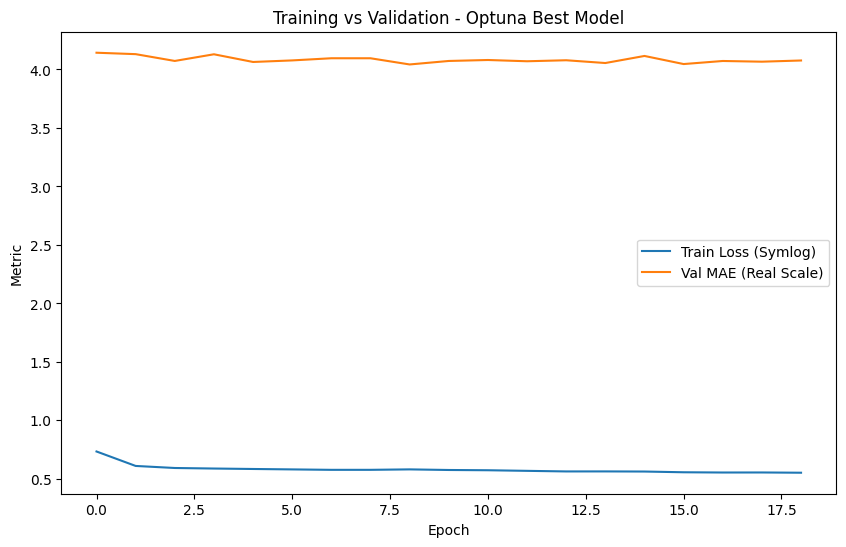

Test MAE  (Real Scale): 1.4037
Test RMSE (Real Scale): 7.7030



In [ ]:

print("OPTUNA BEST INITIALIZATION PARAMETERS")
print(f"Best Trial Validation Loss (Symlog Space): {study.best_trial.value:.4f}")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")
print("="*50 + "\n")

optimal_batch_size = study.best_trial.params["batch_size"]
test_dataset = ImprovedYoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)
test_loader = DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

final_model = ImprovedShallow_xLSTM(
    input_size=len(selected_indices),
    hidden_size=study.best_trial.params["hidden_size"],
    num_targets=len(PREDICTION_TARGETS),
    dropout=study.best_trial.params["dropout"],
    block_type=study.best_trial.params["block_type"]
)

print("Executing final training pass to lock-in optimal weights...")
train_loader_final = DataLoader(ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices), batch_size=optimal_batch_size, shuffle=True, collate_fn=collate_fn_improved_mtl)
val_loader_final = DataLoader(ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices), batch_size=optimal_batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

result = train_model(
    model=final_model,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    criterion=nn.L1Loss(),
    lr=study.best_trial.params["lr"],
    weight_decay=study.best_trial.params["weight_decay"],
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=DEVICE
)

plt.figure(figsize=(10, 6))
plt.plot(result["history"]["train_loss"], label="Train Loss (Symlog)")
plt.plot(result["history"]["val_loss"], label="Val MAE (Real Scale)")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Training vs Validation - Optuna Best Model")
plt.legend()
plt.show()

final_model.load_state_dict(torch.torch.load('best_xlstm_model.pth', map_location=DEVICE))
real_mae, real_rmse = evaluate_real_metrics(final_model, test_loader, DEVICE)

In [ ]:
per_target_results = evaluate_per_target_metrics(final_model, test_loader, DEVICE, PREDICTION_TARGETS)

--- MAE PER TARGET (REAL SCALE) ---
EBITDA       MAE: 1.1280
Net_Income   MAE: 1.5529
ROA          MAE: 1.5296


Training Hybrid xLSTM (mLSTM -> sLSTM)...
Epoch   1/70 | Train Loss: 0.7233 | Val MAE (Real): 4.2367 | LR: 0.001000
Epoch   2/70 | Train Loss: 0.6695 | Val MAE (Real): 4.1198 | LR: 0.001000
Epoch   3/70 | Train Loss: 0.6419 | Val MAE (Real): 4.1056 | LR: 0.001000
Epoch   4/70 | Train Loss: 0.6152 | Val MAE (Real): 4.0875 | LR: 0.001000
Epoch   5/70 | Train Loss: 0.5996 | Val MAE (Real): 4.1007 | LR: 0.001000
Epoch   6/70 | Train Loss: 0.5923 | Val MAE (Real): 4.0806 | LR: 0.001000
Epoch   7/70 | Train Loss: 0.5835 | Val MAE (Real): 4.0834 | LR: 0.001000
Epoch   8/70 | Train Loss: 0.5730 | Val MAE (Real): 4.0837 | LR: 0.001000
Epoch   9/70 | Train Loss: 0.5683 | Val MAE (Real): 4.0674 | LR: 0.001000
Epoch  10/70 | Train Loss: 0.5630 | Val MAE (Real): 4.0678 | LR: 0.001000
Epoch  11/70 | Train Loss: 0.5616 | Val MAE (Real): 4.0621 | LR: 0.001000
Epoch  12/70 | Train Loss: 0.5580 | Val MAE (Real): 4.0668 | LR: 0.001000
Epoch  13/70 | Train Loss: 0.5529 | Val MAE (Real): 4.0833 | LR: 0.001

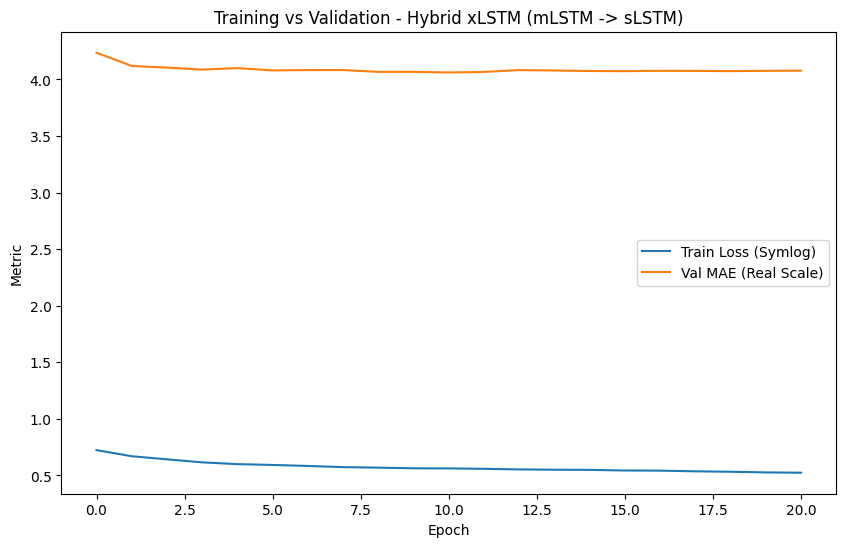


--- HYBRID MODEL OVERALL RESULTS ---
Test MAE  (Real Scale): 1.4586
Test RMSE (Real Scale): 7.7060

--- MAE PER TARGET (REAL SCALE) ---
EBITDA       MAE: 1.1573
Net_Income   MAE: 1.5734
ROA          MAE: 1.6448


In [ ]:
class Hybrid_xLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = len(PREDICTION_TARGETS), dropout: float = 0.2):
        super().__init__()
        self.proj = nn.Linear(input_size, hidden_size)
        slstm_config = sLSTMLayerConfig(backend='vanilla')

        # We configure 2 blocks: 1 mLSTM layer followed by 1 sLSTM layer
        self.xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(slstm=slstm_config),
            mlstm_block=mLSTMBlockConfig(mlstm=mLSTMLayerConfig()),
            context_length=400,
            num_blocks=2,
            embedding_dim=hidden_size,
            slstm_at=[1]  # Index 1 is the second block. Index 0 defaults to mLSTM.
        )

        self.xlstm = xLSTMBlockStack(self.xlstm_config)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size, num_targets)

    def forward(self, x, lengths):
        # x shape: [B, MaxSeq, input_size]
        B, S, _ = x.shape
        x_proj = self.proj(x)

        # Output strictly structured as [B, S, hidden_dim]
        out = self.xlstm(x_proj)

        # Dynamically recover the 'last valid hidden step' taking sequence padding into account
        idx = (lengths - 1).view(-1, 1).expand(-1, out.size(2)).unsqueeze(1).to(out.device)
        last_out = out.gather(1, idx).squeeze(1) # [B, hidden_size]

        hidden = self.dropout(last_out)
        logits = self.head(hidden)

        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

# Hybrid Parameters (Blending aspects from both best runs)
hybrid_params = {
    'hidden_size': 64,
    'dropout': 0.33,
    'lr': 0.001,
    'weight_decay': 0.002,
    'batch_size': 64
}

print("Training Hybrid xLSTM (mLSTM -> sLSTM)...")

test_dataset = ImprovedYoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)
test_loader = DataLoader(test_dataset, batch_size=hybrid_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)
train_loader_hybrid = DataLoader(ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices), batch_size=hybrid_params["batch_size"], shuffle=True, collate_fn=collate_fn_improved_mtl)
val_loader_hybrid = DataLoader(ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices), batch_size=hybrid_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)

hybrid_model = Hybrid_xLSTM(
    input_size=len(selected_indices),
    hidden_size=hybrid_params["hidden_size"],
    num_targets=len(PREDICTION_TARGETS),
    dropout=hybrid_params["dropout"]
)

result = train_model(
    model=hybrid_model,
    train_loader=train_loader_hybrid,
    val_loader=val_loader_hybrid,
    criterion=nn.L1Loss(),
    lr=hybrid_params["lr"],
    weight_decay=hybrid_params["weight_decay"],
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=DEVICE
)

plt.figure(figsize=(10, 6))
plt.plot(result["history"]["train_loss"], label="Train Loss (Symlog)")
plt.plot(result["history"]["val_loss"], label="Val MAE (Real Scale)")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Training vs Validation - Hybrid xLSTM (mLSTM -> sLSTM)")
plt.legend()
plt.show()

hybrid_model.load_state_dict(torch.load('best_xlstm_model.pth', map_location=DEVICE))
print("\n--- HYBRID MODEL OVERALL RESULTS ---")
real_mae_hybrid, real_rmse_hybrid = evaluate_real_metrics(hybrid_model, test_loader, DEVICE)
per_target_results_hybrid = evaluate_per_target_metrics(hybrid_model, test_loader, DEVICE, PREDICTION_TARGETS)

Training Hybrid xLSTM (mLSTM -> mLSTM -> sLSTM)
Final number of parameters: 96,595
Epoch   1/70 | Train Loss: 0.7521 | Val MAE (Real): 4.3835 | LR: 0.001000
Epoch   2/70 | Train Loss: 0.6865 | Val MAE (Real): 4.3103 | LR: 0.001000
Epoch   3/70 | Train Loss: 0.6484 | Val MAE (Real): 4.2327 | LR: 0.001000
Epoch   4/70 | Train Loss: 0.6241 | Val MAE (Real): 4.2299 | LR: 0.001000
Epoch   5/70 | Train Loss: 0.6070 | Val MAE (Real): 4.2113 | LR: 0.001000
Epoch   6/70 | Train Loss: 0.5978 | Val MAE (Real): 4.2005 | LR: 0.001000
Epoch   7/70 | Train Loss: 0.5849 | Val MAE (Real): 4.1789 | LR: 0.001000
Epoch   8/70 | Train Loss: 0.5714 | Val MAE (Real): 4.1695 | LR: 0.001000
Epoch   9/70 | Train Loss: 0.5643 | Val MAE (Real): 4.1656 | LR: 0.001000
Epoch  10/70 | Train Loss: 0.5631 | Val MAE (Real): 4.1689 | LR: 0.001000
Epoch  11/70 | Train Loss: 0.5625 | Val MAE (Real): 4.1760 | LR: 0.001000
Epoch  12/70 | Train Loss: 0.5553 | Val MAE (Real): 4.1858 | LR: 0.001000
Epoch  13/70 | Train Loss: 0.

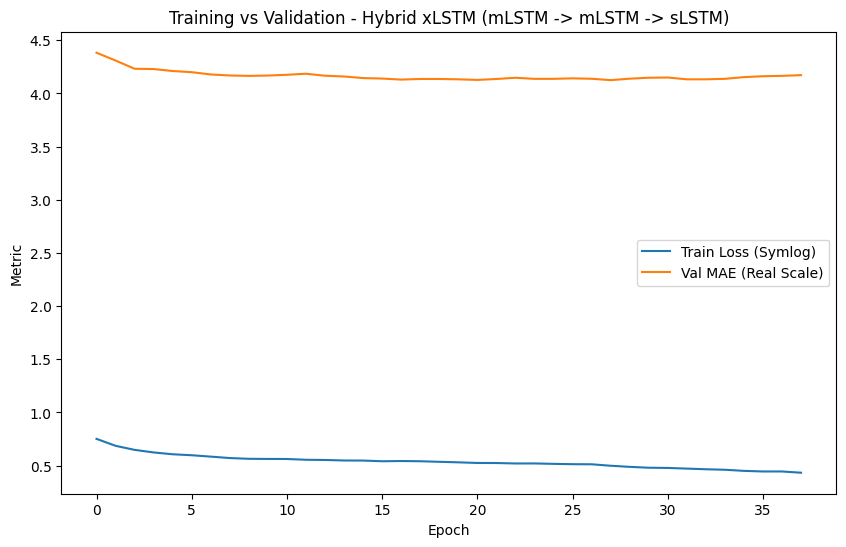


--- HYBRID MODEL OVERALL RESULTS ---
Test MAE  (Real Scale): 1.4204
Test RMSE (Real Scale): 7.7020

--- MAE PER TARGET (REAL SCALE) ---
EBITDA       MAE: 1.1379
Net_Income   MAE: 1.5715
ROA          MAE: 1.5514


In [ ]:
class Hybrid_xLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = len(PREDICTION_TARGETS), dropout: float = 0.2):
        super().__init__()
        self.proj = nn.Linear(input_size, hidden_size)
        slstm_config = sLSTMLayerConfig(backend='vanilla')

        self.xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(slstm=slstm_config),
            mlstm_block=mLSTMBlockConfig(mlstm=mLSTMLayerConfig()),
            context_length=400,
            num_blocks=3,
            embedding_dim=hidden_size,
            slstm_at=[2]
        )

        self.xlstm = xLSTMBlockStack(self.xlstm_config)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size, num_targets)

    def forward(self, x, lengths):
        # x shape: [B, MaxSeq, input_size]
        B, S, _ = x.shape
        x_proj = self.proj(x)

        # Output strictly structured as [B, S, hidden_dim]
        out = self.xlstm(x_proj)

        # Dynamically recover the 'last valid hidden step' taking sequence padding into account
        idx = (lengths - 1).view(-1, 1).expand(-1, out.size(2)).unsqueeze(1).to(out.device)
        last_out = out.gather(1, idx).squeeze(1) # [B, hidden_size]

        hidden = self.dropout(last_out)
        logits = self.head(hidden)

        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

hybrid_params = {
    'hidden_size': 64,
    'dropout': 0.33,
    'lr': 0.001,
    'weight_decay': 0.002,
    'batch_size': 64
}

print("Training Hybrid xLSTM (mLSTM -> mLSTM -> sLSTM)")

test_dataset = ImprovedYoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)
test_loader = DataLoader(test_dataset, batch_size=hybrid_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)
train_loader_hybrid = DataLoader(ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices), batch_size=hybrid_params["batch_size"], shuffle=True, collate_fn=collate_fn_improved_mtl)
val_loader_hybrid = DataLoader(ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices), batch_size=hybrid_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)

hybrid_model = Hybrid_xLSTM(
    input_size=len(selected_indices),
    hidden_size=hybrid_params["hidden_size"],
    num_targets=len(PREDICTION_TARGETS),
    dropout=hybrid_params["dropout"]
)

total_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f"Final number of parameters: {total_params:,}")

result = train_model(
    model=hybrid_model,
    train_loader=train_loader_hybrid,
    val_loader=val_loader_hybrid,
    criterion=nn.L1Loss(),
    lr=hybrid_params["lr"],
    weight_decay=hybrid_params["weight_decay"],
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=DEVICE
)

plt.figure(figsize=(10, 6))
plt.plot(result["history"]["train_loss"], label="Train Loss (Symlog)")
plt.plot(result["history"]["val_loss"], label="Val MAE (Real Scale)")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Training vs Validation - Hybrid xLSTM (mLSTM -> mLSTM -> sLSTM)")
plt.legend()
plt.show()

hybrid_model.load_state_dict(torch.load('best_xlstm_model.pth', map_location=DEVICE))
print("\n--- HYBRID MODEL OVERALL RESULTS ---")
real_mae_hybrid, real_rmse_hybrid = evaluate_real_metrics(hybrid_model, test_loader, DEVICE)
per_target_results_hybrid = evaluate_per_target_metrics(hybrid_model, test_loader, DEVICE, PREDICTION_TARGETS)

Training Improved Hybrid xLSTM (Explicitly Split Configurations)
Final number of parameters: 96,595
Epoch   1/70 | Train Loss: 0.7145 | Val MAE (Real): 4.0688 | LR: 0.004400
Epoch   2/70 | Train Loss: 0.5996 | Val MAE (Real): 4.0539 | LR: 0.004400
Epoch   3/70 | Train Loss: 0.5780 | Val MAE (Real): 4.0817 | LR: 0.004400
Epoch   4/70 | Train Loss: 0.5730 | Val MAE (Real): 4.0655 | LR: 0.004400
Epoch   5/70 | Train Loss: 0.5724 | Val MAE (Real): 4.0536 | LR: 0.004400
Epoch   6/70 | Train Loss: 0.5671 | Val MAE (Real): 4.0782 | LR: 0.004400
Epoch   7/70 | Train Loss: 0.5643 | Val MAE (Real): 4.0650 | LR: 0.004400
Epoch   8/70 | Train Loss: 0.5627 | Val MAE (Real): 4.0682 | LR: 0.002200
Epoch   9/70 | Train Loss: 0.5608 | Val MAE (Real): 4.0665 | LR: 0.002200
Epoch  10/70 | Train Loss: 0.5583 | Val MAE (Real): 4.0714 | LR: 0.002200
Epoch  11/70 | Train Loss: 0.5585 | Val MAE (Real): 4.0706 | LR: 0.002200
Epoch  12/70 | Train Loss: 0.5575 | Val MAE (Real): 4.0783 | LR: 0.002200
Epoch  13/70

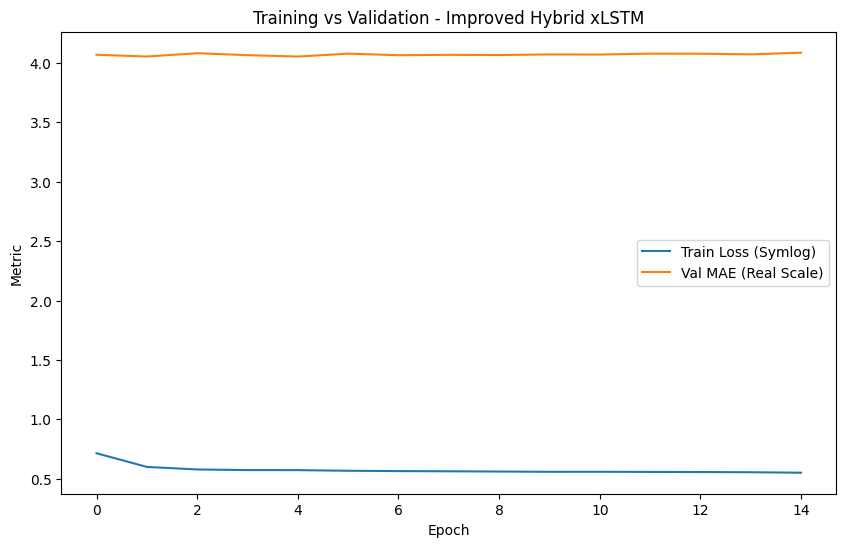


--- IMPROVED HYBRID MODEL OVERALL RESULTS ---
Test MAE  (Real Scale): 1.4189
Test RMSE (Real Scale): 7.7005

--- MAE PER TARGET (REAL SCALE) ---
EBITDA       MAE: 1.1625
Net_Income   MAE: 1.5600
ROA          MAE: 1.5336


In [ ]:
class ImprovedHybrid_xLSTM(nn.Module):
    def __init__(self, input_size: int, embedding_dim: int = 64, num_targets: int = len(PREDICTION_TARGETS)):
        super().__init__()
        self.proj = nn.Linear(input_size, embedding_dim)

        # 1) sLSTM config (Strictly Trial 5)
        # Inside the block config we can explicitly override the internal hidden dimension
        # setting it to 32 exactly as Trial 5 suggested, and applying block-level dropout
        slstm_config = sLSTMLayerConfig(
            backend='vanilla',
            hidden_size=32,
            dropout=0.334    # Extracted from Trial 5
        )

        # 2) mLSTM config (Strictly Trial 63)
        # The xLSTM stack requires a shared "embedding_dim" connecting the layers (we use 64).
        # We can reach the desired 128 hidden_size from Trial 63 inside the mLSTM block
        # by using a proj_factor of 2.0 (embedding_dim 64 * 2.0 = 128 inner dimension)
        mlstm_config = mLSTMLayerConfig(
            num_heads=4,
            proj_factor=2.0, # Scales internal capacity to 128
            dropout=0.330    # Extracted from Trial 63
        )

        self.xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(
                slstm=slstm_config,
            ),
            mlstm_block=mLSTMBlockConfig(
                mlstm=mlstm_config,
            ),
            context_length=400,
            num_blocks=3,
            embedding_dim=embedding_dim, # 64 -> Transport bus between blocks
            slstm_at=[2]
        )

        self.xlstm = xLSTMBlockStack(self.xlstm_config)
        self.head_dropout = nn.Dropout(p=0.33)
        self.head = nn.Linear(embedding_dim, num_targets)

    def forward(self, x, lengths):
        B, S, _ = x.shape
        out = self.proj(x)
        out = self.xlstm(out)

        idx = (lengths - 1).view(-1, 1).expand(-1, out.size(2)).unsqueeze(1).to(out.device)
        last_out = out.gather(1, idx).squeeze(1)

        hidden = self.head_dropout(last_out)
        logits = self.head(hidden)

        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

# Because the optimizer settings (lr, weight_decay, batch_size) apply to the whole loop,
# we still need to pick a global setup here. We will use the aggressive ones from mLSTM (Trial 63)
# since it occupies 2 of the 3 blocks, but you could tune this later.
lr_global = 0.0044
weight_decay_global = 0.0054
batch_size_global = 64

print("Training Improved Hybrid xLSTM (Explicitly Split Configurations)")

test_dataset = ImprovedYoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)
test_loader = DataLoader(test_dataset, batch_size=batch_size_global, shuffle=False, collate_fn=collate_fn_improved_mtl)
train_loader_hybrid = DataLoader(ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices), batch_size=batch_size_global, shuffle=True, collate_fn=collate_fn_improved_mtl)
val_loader_hybrid = DataLoader(ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices), batch_size=batch_size_global, shuffle=False, collate_fn=collate_fn_improved_mtl)

hybrid_model = ImprovedHybrid_xLSTM(
    input_size=len(selected_indices),
    embedding_dim=64,
    num_targets=len(PREDICTION_TARGETS)
)

total_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f"Final number of parameters: {total_params:,}")

result = train_model(
    model=hybrid_model,
    train_loader=train_loader_hybrid,
    val_loader=val_loader_hybrid,
    criterion=nn.L1Loss(),
    lr=lr_global,
    weight_decay=weight_decay_global,
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=DEVICE
)

plt.figure(figsize=(10, 6))
plt.plot(result["history"]["train_loss"], label="Train Loss (Symlog)")
plt.plot(result["history"]["val_loss"], label="Val MAE (Real Scale)")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Training vs Validation - Improved Hybrid xLSTM")
plt.legend()
plt.show()

hybrid_model.load_state_dict(torch.load('best_xlstm_model.pth', map_location=DEVICE))
print("\n--- IMPROVED HYBRID MODEL OVERALL RESULTS ---")
real_mae_hybrid, real_rmse_hybrid = evaluate_real_metrics(hybrid_model, test_loader, DEVICE)
per_target_results_hybrid = evaluate_per_target_metrics(hybrid_model, test_loader, DEVICE, PREDICTION_TARGETS)

In [ ]:
print("Starting explicit Hybrid xLSTM Optimization Sweep...")

hybrid_study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
hybrid_study.optimize(objective_hybrid, n_trials=OPTUNA_TRIALS)

print("\n" + "="*50)
print("OPTUNA BEST HYBRID INITIALIZATION PARAMETERS")
print(f"Best Trial Validation MAE (Real Scale): {hybrid_study.best_trial.value:.4f}")
for key, value in hybrid_study.best_trial.params.items():
    print(f"  {key}: {value}")
print("="*50 + "\n")

[I 2026-06-15 16:01:57,344] A new study created in memory with name: no-name-90d90e31-fcdf-470b-b9c5-2e82d310a9c3


Starting explicit Hybrid xLSTM Optimization Sweep...


[I 2026-06-15 16:05:48,934] Trial 0 finished with value: 4.090086827589118 and parameters: {'embedding_dim': 64, 'mlstm_proj_factor': 2.0, 'mlstm_num_heads': 4, 'slstm_hidden_size': 32, 'dropout_mlstm': 0.16349061261619066, 'dropout_slstm': 0.2935361420278125, 'dropout_global': 0.3612031825350087, 'lr_mlstm': 0.003638613814568572, 'lr_slstm': 0.0008279240207193653, 'weight_decay': 0.0007218658204307097, 'batch_size': 128}. Best is trial 0 with value: 4.090086827589118.
[I 2026-06-15 16:24:40,582] Trial 1 finished with value: 4.084993800909623 and parameters: {'embedding_dim': 64, 'mlstm_proj_factor': 1.5, 'mlstm_num_heads': 2, 'slstm_hidden_size': 32, 'dropout_mlstm': 0.21140709114470121, 'dropout_slstm': 0.24889897561293114, 'dropout_global': 0.37539696425290403, 'lr_mlstm': 0.0003037360062437294, 'lr_slstm': 0.00311090453433751, 'weight_decay': 0.0026780487569633645, 'batch_size': 32}. Best is trial 1 with value: 4.084993800909623.
[I 2026-06-15 16:29:02,541] Trial 2 finished with va

### Best params found above

In [16]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

best_params = {
    'embedding_dim': 32,
    'mlstm_proj_factor': 1.5,
    'mlstm_num_heads': 2,
    'slstm_hidden_size': 64,
    'dropout_mlstm': 0.3973836663012612,
    'dropout_slstm': 0.10021604465128908,
    'dropout_global': 0.22026512174169163,
    'lr_mlstm': 0.0009056609632336968,
    'lr_slstm': 0.0011106222378062082,
    'weight_decay': 0.00017545450770331032,
    'batch_size': 32
}

# Increase patience and epochs to allow the decoupled learning rates to converge fully
FINAL_EPOCHS = 150
FINAL_PATIENCE = 20

print("Preparing DataLoaders for Final Training...")

# 3. Instantiate DataLoaders
train_ds = ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices)
val_ds = ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices)
test_ds = ImprovedYoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)

train_loader = DataLoader(train_ds, batch_size=best_params['batch_size'], shuffle=True, collate_fn=collate_fn_improved_mtl)
val_loader = DataLoader(val_ds, batch_size=best_params['batch_size'], shuffle=False, collate_fn=collate_fn_improved_mtl)
test_loader = DataLoader(test_ds, batch_size=best_params['batch_size'], shuffle=False, collate_fn=collate_fn_improved_mtl)

print("Initializing Final Hybrid xLSTM Model...")

# 4. Build the Final Model architecture
final_model = TunableHybrid_xLSTM(
    input_size=len(selected_indices),
    embedding_dim=best_params['embedding_dim'],
    mlstm_proj_factor=best_params['mlstm_proj_factor'],
    mlstm_num_heads=best_params['mlstm_num_heads'],
    slstm_hidden_size=best_params['slstm_hidden_size'],
    dropout_mlstm=best_params['dropout_mlstm'],
    dropout_slstm=best_params['dropout_slstm'],
    dropout_global=best_params['dropout_global']
).to(DEVICE)

# 5. Create the Decoupled Optimizer to feed different engines with different rates
mlstm_params = [p for n, p in final_model.named_parameters() if 'mlstm' in n]
slstm_params = [p for n, p in final_model.named_parameters() if 'slstm' in n]
other_params = [p for n, p in final_model.named_parameters() if 'mlstm' not in n and 'slstm' not in n]

final_optimizer = torch.optim.AdamW([
    {'params': mlstm_params, 'lr': best_params['lr_mlstm']},
    {'params': slstm_params, 'lr': best_params['lr_slstm']},
    {'params': other_params, 'lr': best_params['lr_mlstm']} # Default projections/head to the mLSTM rate
], weight_decay=best_params['weight_decay'])

criterion = RealScaleL1Loss()


# 6. Train the Model (trial=None ensures it runs as a standard training loop)
final_val_loss = train_model_v2(
    model=final_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=final_optimizer,
    epochs=FINAL_EPOCHS,
    patience=FINAL_PATIENCE,
    device=DEVICE,
    trial=None
)

print(f"\nFinal Validation Loss achieved: {final_val_loss:.4f}")

# 7. Evaluate on Unseen Test Set
print("\n" + "="*50)
print("FINAL TEST SET EVALUATION")
print("="*50)

# Load the mathematically optimal weights saved by early stopping
final_model.load_state_dict(torch.load('best_xlstm_model.pth', map_location=DEVICE))

real_mae, real_rmse = evaluate_real_metrics(final_model, test_loader, DEVICE)
per_target_results = evaluate_per_target_metrics(final_model, test_loader, DEVICE, PREDICTION_TARGETS)

Preparing DataLoaders for Final Training...
Initializing Final Hybrid xLSTM Model...
Epoch   1/150 | Train Loss: 4.6670 | Val MAE (Real): 4.0670 | LR: 0.000906
Epoch   2/150 | Train Loss: 4.5313 | Val MAE (Real): 4.0670 | LR: 0.000906
Epoch   3/150 | Train Loss: 4.5041 | Val MAE (Real): 4.0700 | LR: 0.000906
Epoch   4/150 | Train Loss: 4.4784 | Val MAE (Real): 4.0661 | LR: 0.000906
Epoch   5/150 | Train Loss: 4.4659 | Val MAE (Real): 4.0528 | LR: 0.000906
Epoch   6/150 | Train Loss: 4.4595 | Val MAE (Real): 4.0471 | LR: 0.000906
Epoch   7/150 | Train Loss: 4.4490 | Val MAE (Real): 4.0582 | LR: 0.000906
Epoch   8/150 | Train Loss: 4.4439 | Val MAE (Real): 4.0543 | LR: 0.000906
Epoch   9/150 | Train Loss: 4.4418 | Val MAE (Real): 4.0534 | LR: 0.000906
Epoch  10/150 | Train Loss: 4.4400 | Val MAE (Real): 4.0678 | LR: 0.000906
Epoch  11/150 | Train Loss: 4.4341 | Val MAE (Real): 4.0476 | LR: 0.000906
Epoch  12/150 | Train Loss: 4.4305 | Val MAE (Real): 4.0446 | LR: 0.000906
Epoch  13/150 |